In [6]:
from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Configuration
# ============================================================

DATA_ROOT = Path("data/stabilization_time")
RESULTS_ROOT = Path("results/stabilization_time")
GRAPHS_ROOT = Path("graphs/stabilization_time")

TARGET_DENSITY = 0.85
CELL_RADIUS = 1.0

EXPECTED_SEEDS_PER_N = 50
EXPECTED_FIRST_STEP = 0
EXPECTED_LAST_STEP = 1000

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
GRAPHS_ROOT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Parse filenames
# ============================================================

FILE_PATTERN = re.compile(
    r"culture_initial_number_of_cells=(?P<N>[\d_]+)"
    r"_density=(?P<density>[\d.]+)"
    r".*?"
    r"_rng_seed=(?P<seed>\d+)"
    r"_step=(?P<step>\d+)\.dat$"
)


def parse_filename(filepath):
    """
    Extract simulation metadata from a .dat filename.
    """
    match = FILE_PATTERN.search(filepath.name)

    if match is None:
        return None

    return {
        "filepath": filepath,
        "relative_path": str(filepath.relative_to(DATA_ROOT)),
        "N": int(match.group("N").replace("_", "")),
        "density": float(match.group("density")),
        "seed": int(match.group("seed")),
        "step": int(match.group("step")),
        "size_bytes": filepath.stat().st_size,
    }


def collect_files():
    """
    Find all matching .dat files inside stabilization_time/.
    """
    records = []

    for filepath in DATA_ROOT.rglob("*.dat"):
        metadata = parse_filename(filepath)

        if metadata is None:
            continue

        if not np.isclose(metadata["density"], TARGET_DENSITY):
            continue

        records.append(metadata)

    files_df = pd.DataFrame(records)

    if files_df.empty:
        raise FileNotFoundError(
            f"No matching files were found in {DATA_ROOT.resolve()}"
        )

    return files_df.sort_values(
        ["N", "density", "seed", "step"]
    ).reset_index(drop=True)

In [7]:
def read_xy_positions(filepath):
    """
    Read only x and y positions from one simulation file.
    """
    positions = np.loadtxt(
        filepath,
        delimiter=",",
        skiprows=1,
        usecols=(0, 1),
        dtype=float,
    )

    return np.atleast_2d(positions)


def calculate_box_side(N, density, cell_radius=1.0):
    """
    Calculate the side of the periodic square box.
    """
    cell_area = np.pi * cell_radius**2
    return np.sqrt(N * cell_area / density)


def apply_minimum_image(delta_positions, box_side):
    """
    Correct displacements using periodic boundary conditions.
    """
    return (
        delta_positions
        - box_side * np.round(delta_positions / box_side)
    )

In [8]:
def calculate_displacement_curves(files_df):
    """
    Calculate displacement statistics for every seed and time step.

    The displacement at step t is calculated relative to step t - 1.
    """
    results = []
    problems = []

    grouped = files_df.groupby(
        ["N", "density", "seed"],
        sort=True,
    )

    for (N, density, seed), seed_files in tqdm(
        grouped,
        total=grouped.ngroups,
        desc="Processing seeds",
    ):
        seed_files = seed_files.sort_values("step")

        box_side = calculate_box_side(
            N=N,
            density=density,
            cell_radius=CELL_RADIUS,
        )

        previous_positions = None
        previous_step = None

        for row in seed_files.itertuples(index=False):
            current_positions = read_xy_positions(row.filepath)

            # Check whether the file contains all cells
            if current_positions.shape[0] != N:
                message = (
                    f"Expected {N} cells but found "
                    f"{current_positions.shape[0]} in {row.filepath}. "
                    f"Skipping step {row.step}."
                )

                print(message)

                problems.append(
                    {
                        "N": N,
                        "density": density,
                        "seed": seed,
                        "step": row.step,
                        "filepath": str(row.filepath),
                        "expected_cells": N,
                        "found_cells": current_positions.shape[0],
                        "problem": message,
                    }
                )

                # Break the chain. The following valid step must not
                # be compared with a configuration two steps earlier.
                previous_positions = None
                previous_step = None

                continue

            # Calculate displacement relative to the preceding valid step
            if previous_positions is not None:
                if row.step != previous_step + 1:
                    problems.append(
                        {
                            "N": N,
                            "density": density,
                            "seed": seed,
                            "previous_step": previous_step,
                            "current_step": row.step,
                            "problem": "Non-consecutive steps",
                        }
                    )

                    previous_positions = current_positions
                    previous_step = row.step
                    continue

                delta_positions = (
                    current_positions - previous_positions
                )

                delta_positions = apply_minimum_image(
                    delta_positions,
                    box_side,
                )

                displacements = (
                    np.linalg.norm(
                        delta_positions,
                        axis=1,
                    )
                    / CELL_RADIUS
                )

                results.append(
                    {
                        "N": N,
                        "density": density,
                        "seed": seed,
                        "step": row.step,
                        "mean_displacement": np.mean(
                            displacements
                        ),
                        "median_displacement": np.median(
                            displacements
                        ),
                        "p95_displacement": np.percentile(
                            displacements,
                            95,
                        ),
                        "max_displacement": np.max(
                            displacements
                        ),
                    }
                )

            # Save the current valid configuration for the next step
            previous_positions = current_positions
            previous_step = row.step

    results_df = pd.DataFrame(results)
    problems_df = pd.DataFrame(problems)

    if results_df.empty:
        raise RuntimeError(
            "No displacement values were calculated."
        )

    return results_df, problems_df

In [9]:
def summarize_displacements(results_df):
    """
    Calculate mean, standard deviation and SEM across seeds.
    """
    summary = (
        results_df
        .groupby(["N", "density", "step"])
        .agg(
            mean_displacement=(
                "mean_displacement",
                "mean",
            ),
            std_mean_displacement=(
                "mean_displacement",
                "std",
            ),
            median_mean_displacement=(
                "mean_displacement",
                "median",
            ),
            p95_displacement=(
                "p95_displacement",
                "mean",
            ),
            std_p95_displacement=(
                "p95_displacement",
                "std",
            ),
            median_p95_displacement=(
                "p95_displacement",
                "median",
            ),
            number_of_seeds=(
                "seed",
                "nunique",
            ),
        )
        .reset_index()
    )

    summary["sem_mean_displacement"] = (
        summary["std_mean_displacement"]
        / np.sqrt(summary["number_of_seeds"])
    )

    summary["sem_p95_displacement"] = (
        summary["std_p95_displacement"]
        / np.sqrt(summary["number_of_seeds"])
    )

    return summary

In [10]:
def plot_displacement(
    summary,
    metric,
    sem_metric,
    ylabel,
    filename,
    logarithmic=False,
    xlim=None,
    ylim=None,
    vertical_step=None,
):
    """
    Plot one displacement statistic as a function of time.

    Parameters
    ----------
    summary : pandas.DataFrame
        Summary containing one curve for each N.
    metric : str
        Column containing the mean value to plot.
    sem_metric : str
        Column containing the standard error.
    ylabel : str
        Label for the y-axis.
    filename : str
        Base filename, without extension.
    logarithmic : bool, optional
        Whether to use logarithmic scale on the y-axis.
    xlim : tuple or None, optional
        Limits for the x-axis, for example (0, 200).
    ylim : tuple or None, optional
        Limits for the y-axis, for example (1e-5, 1e-2).
    vertical_step : int, float or None, optional
        Step at which to draw a vertical dashed line.
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    for N, data_N in summary.groupby("N"):
        data_N = data_N.sort_values("step")

        step = data_N["step"].to_numpy()
        values = data_N[metric].to_numpy()
        errors = data_N[sem_metric].to_numpy()

        ax.plot(
            step,
            values,
            label=f"N = {N:,}".replace(",", "_"),
        )

        lower = np.maximum(values - errors, 0)
        upper = values + errors

        ax.fill_between(
            step,
            lower,
            upper,
            alpha=0.2,
        )

    if logarithmic:
        ax.set_yscale("log")

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        if logarithmic and ylim[0] <= 0:
            raise ValueError(
                "The lower y limit must be positive "
                "when using a logarithmic scale."
            )

        ax.set_ylim(ylim)

    # Optional stabilization-time marker
    if vertical_step is not None:
        ax.axvline(
            x=vertical_step,
            linestyle="--",
            linewidth=1.5,
            label=fr"$t={vertical_step}$",
        )

    ax.set_xlabel("Time step")
    ax.set_ylabel(ylabel)
    ax.set_title(
        rf"Initial mechanical relaxation, "
        rf"$\rho={TARGET_DENSITY}$"
    )
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    output_filename = filename

    if xlim is not None or ylim is not None:
        output_filename += "_zoom"

    png_path = GRAPHS_ROOT / f"{output_filename}.png"
    pdf_path = GRAPHS_ROOT / f"{output_filename}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

In [11]:
files_df = collect_files()

print("Files found:")
print(
    files_df.groupby("N").agg(
        seeds=("seed", "nunique"),
        files=("filepath", "count"),
        first_step=("step", "min"),
        last_step=("step", "max"),
    )
)

# Save the raw-file manifest before any possible deletion
manifest_path = RESULTS_ROOT / "raw_files_manifest.csv.gz"

files_df[
    [
        "relative_path",
        "N",
        "density",
        "seed",
        "step",
        "size_bytes",
    ]
].to_csv(
    manifest_path,
    index=False,
    compression="gzip",
)

results_df, problems_df = calculate_displacement_curves(
    files_df
)

summary_df = summarize_displacements(
    results_df
)

seed_results_path = (
    RESULTS_ROOT / "displacement_by_seed.csv.gz"
)
summary_path = (
    RESULTS_ROOT / "displacement_summary.csv.gz"
)
problems_path = (
    RESULTS_ROOT / "processing_problems.csv"
)

results_df.to_csv(
    seed_results_path,
    index=False,
    compression="gzip",
)

summary_df.to_csv(
    summary_path,
    index=False,
    compression="gzip",
)

problems_df.to_csv(
    problems_path,
    index=False,
)

Files found:
       seeds  files  first_step  last_step
N                                         
500       50  50050           0       1000
1000      50  50050           0       1000
2500      50  50050           0       1000
5000      50  50050           0       1000
10000     50  50050           0       1000


Processing seeds: 100%|██████████| 250/250 [20:02<00:00,  4.81s/it]


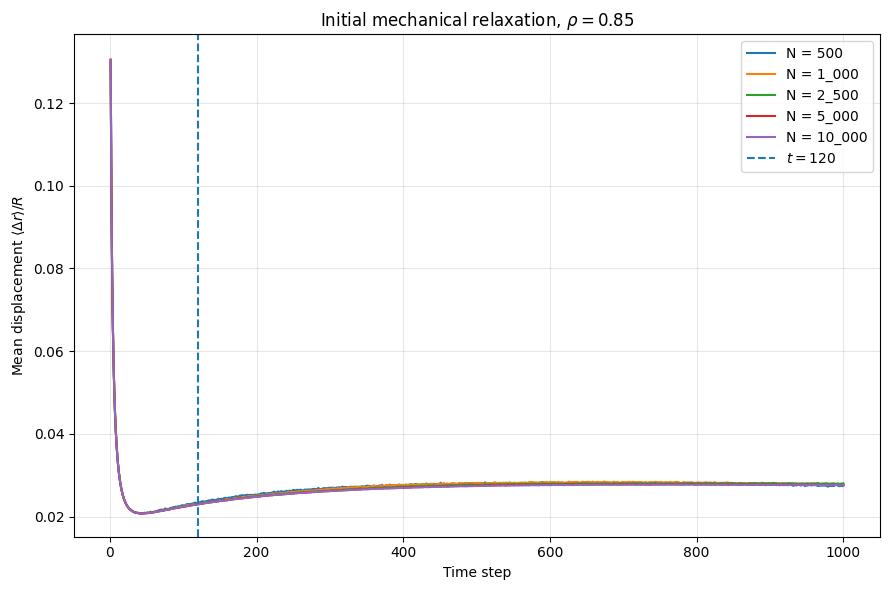

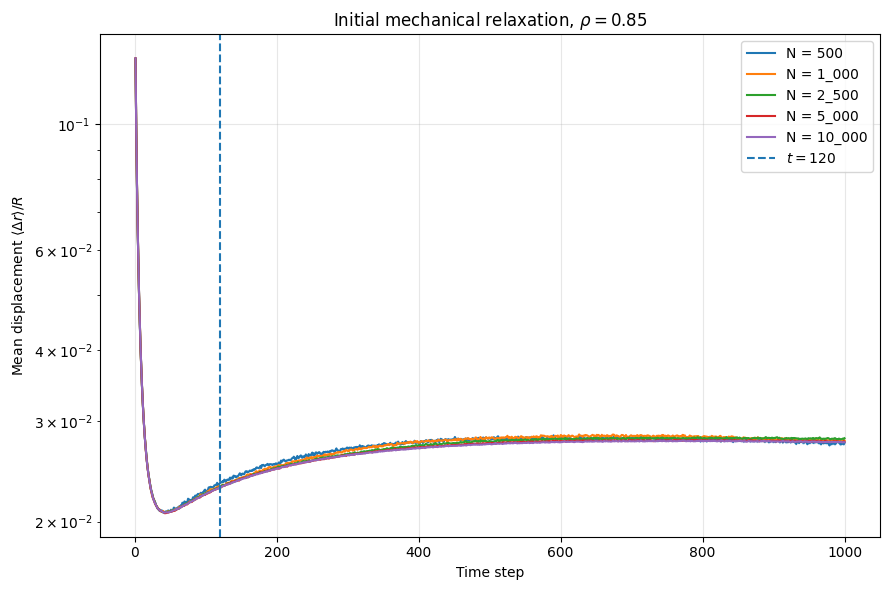

In [12]:
plot_displacement(
    summary=summary_df,
    metric="mean_displacement",
    sem_metric="sem_mean_displacement",
    ylabel=r"Mean displacement $\langle\Delta r\rangle/R$",
    filename="mean_displacement_linear",
    logarithmic=False,
    vertical_step=120,
)

plot_displacement(
    summary=summary_df,
    metric="mean_displacement",
    sem_metric="sem_mean_displacement",
    ylabel=r"Mean displacement $\langle\Delta r\rangle/R$",
    filename="mean_displacement_log",
    logarithmic=True,
    vertical_step=120,
)

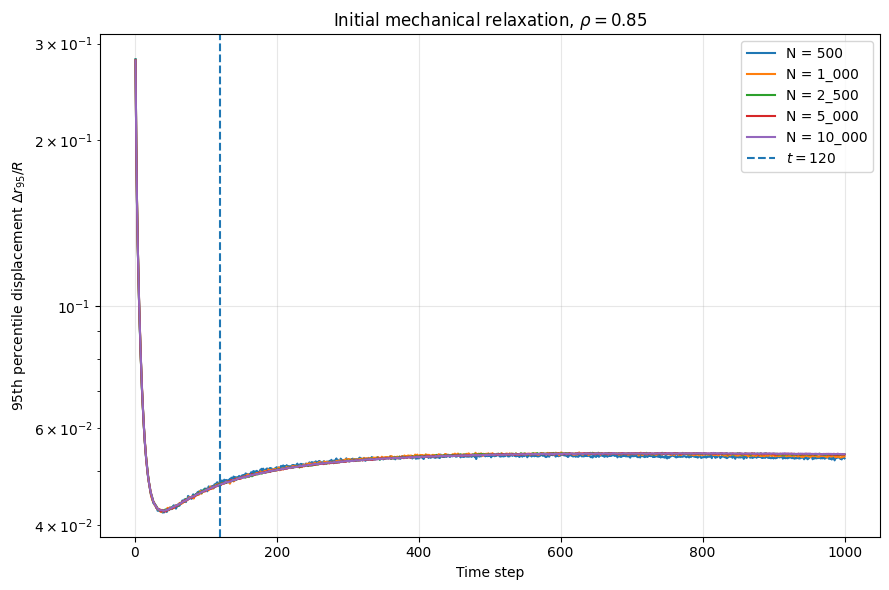

In [13]:
plot_displacement(
    summary=summary_df,
    metric="p95_displacement",
    sem_metric="sem_p95_displacement",
    ylabel=r"95th percentile displacement $\Delta r_{95}/R$",
    filename="p95_displacement_log",
    logarithmic=True,
    vertical_step=120,
)

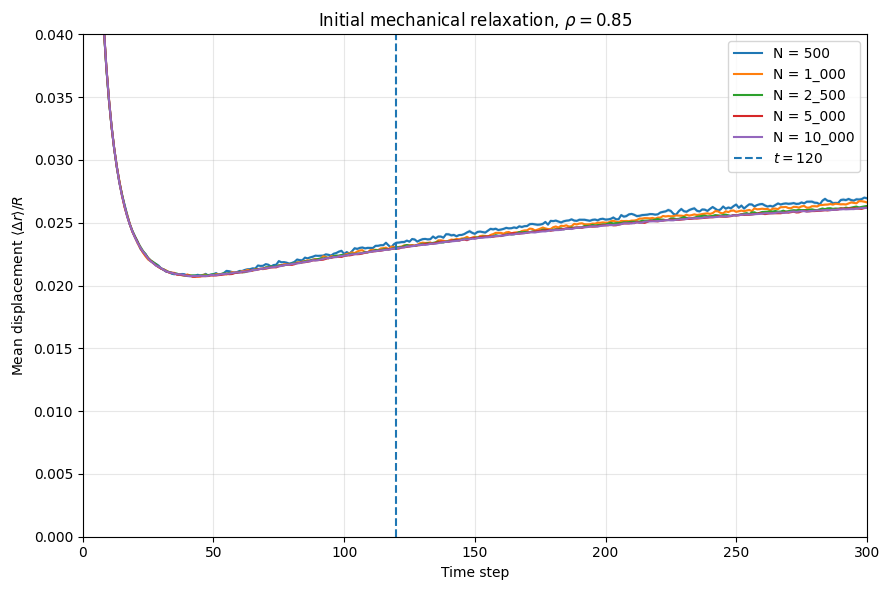

In [14]:
plot_displacement(
    summary=summary_df,
    metric="mean_displacement",
    sem_metric="sem_mean_displacement",
    ylabel=r"Mean displacement $\langle\Delta r\rangle/R$",
    filename="mean_displacement_linear",
    logarithmic=False,
    xlim=(0, 300),
    ylim=(0, 0.04),
    vertical_step=120,
)